# Chromatin PTR analysis
February 32, 2024

Update PTR analysis of latest chromatin deconvolution results. Higher resolution chromatin results. Goal is to summarize a gene's cycling chromatin with a top k values of cycling chromatin.

Possibly sweep for what k values can be reasonable. Maybe think through how we can sweep for an appropriate k.

In [119]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
import glob

outdir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)


In [121]:
from src.timer import Timer

timer = Timer()

peak_to_trough_analysis.load_ptr_files()
peak_to_trough_analysis.sort_gene_ptrs()
peak_to_trough_analysis.compute_gene_ptr_rank_per_k()

timer.get_time()

'00:00:19.06'

In [144]:
failed_genes = peak_to_trough_analysis.undropped_ptrs_df[peak_to_trough_analysis.undropped_ptrs_df[0].isna()]
print(len(failed_genes), "genes failed to deconvolve")
failed_genes.tail(2)

# save to disk and write
# ('data/reference_data/geneset_nondub_w_prom_genebodies_missing_temp_2024-02-29.csv').set_index('orf_name')

48 genes failed to deconvolve


,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
orf_name,,,,,,,,,,,,,,,,,,,,,
YNL126W,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YOL005C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
# 48 genes did not deconvolve, not due to a coverage issue.
# Testing one of the genes:

from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel

config = load_yl_rg1_vst_config(1)
chromatin_model = ChromatinModel(config)


gene_name = "YOL005C"

chromatin_model.load_mnase_gene(gene_name)
chromatin_model.create_deconvolution_bins()


Loading MNase reads for YOL005C/RPB11...Loading chromosome reads: 15
Done.


In [ ]:
chromatin_model.gamma = 0.006
chromatin_model.deconvolve()

Deconvolving with gamma=0.006, gamma_prime=0


In [ ]:
from src.model import Model
ge_model = Model(config, gene_name)
ge_model.deconvolve_find_optimal_gamma(False)

In [ ]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model)

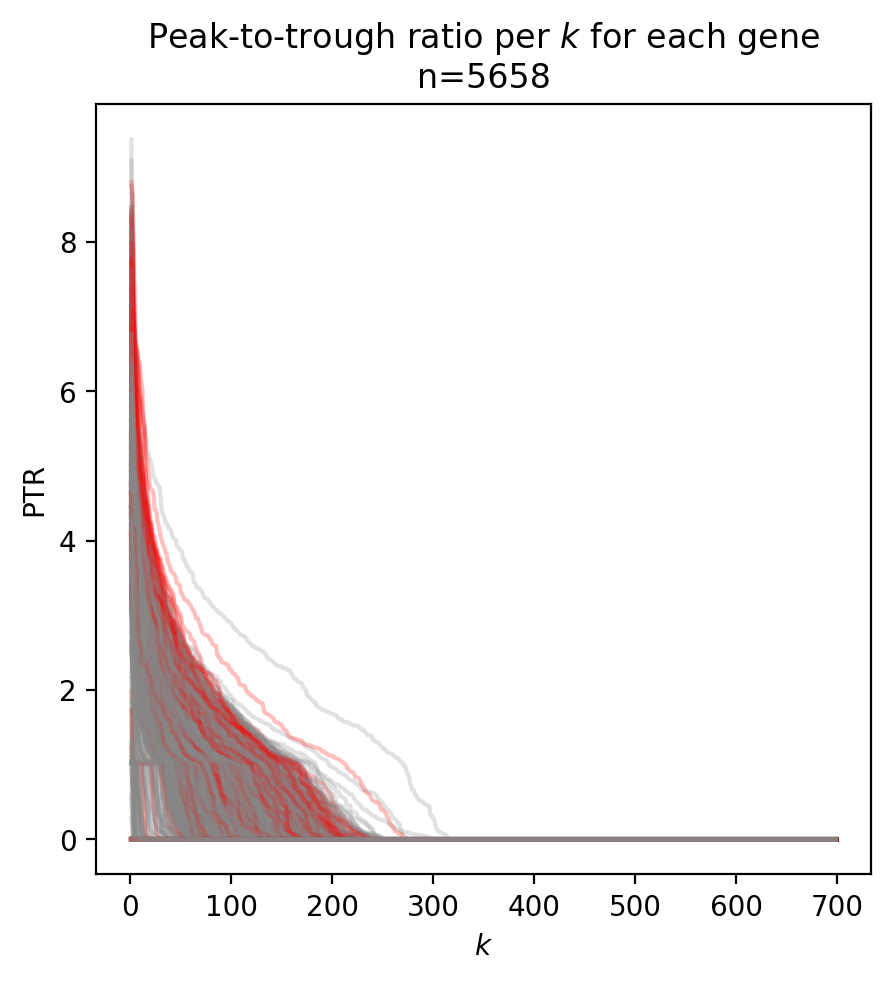

In [122]:
peak_to_trough_analysis.plot_ptr_k_gene()

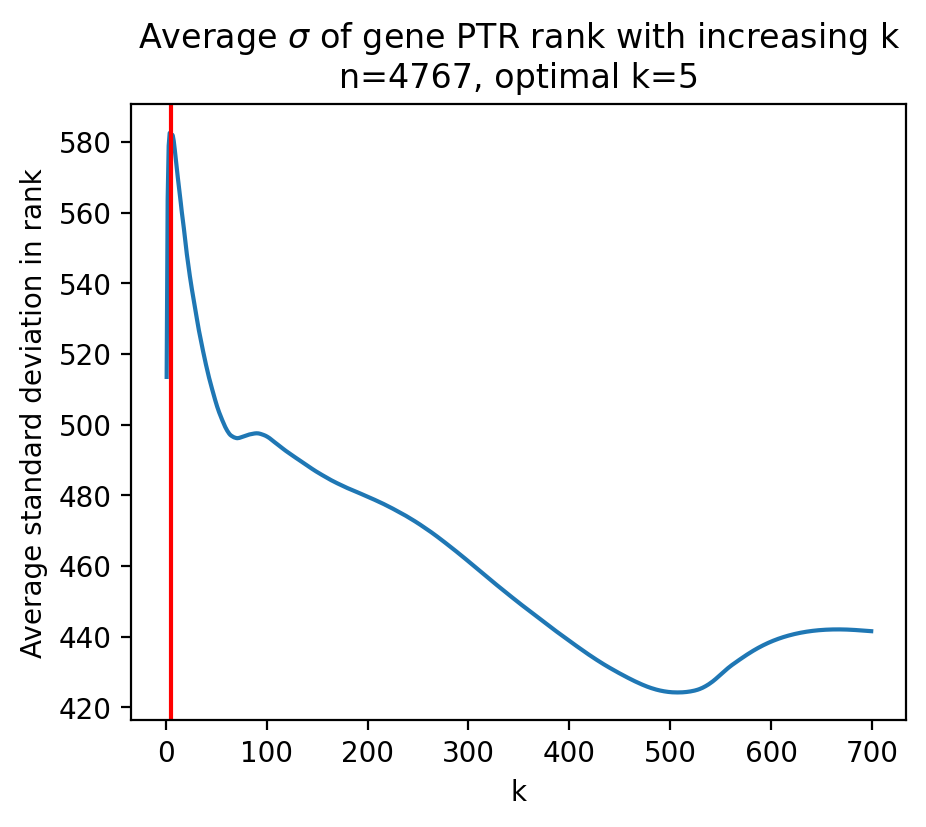

In [5]:
peak_to_trough_analysis.compute_optimal_k()

In [6]:
peak_to_trough_analysis.set_optimal_k(60)

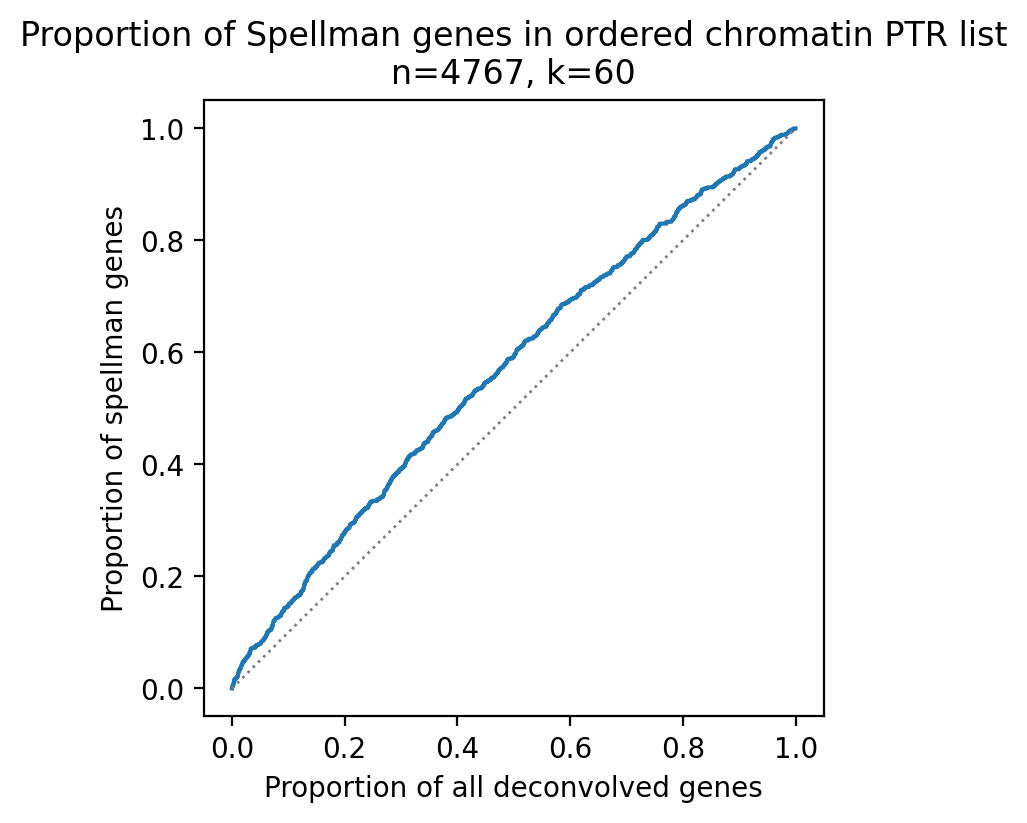

In [7]:
peak_to_trough_analysis.spellman_analysis()

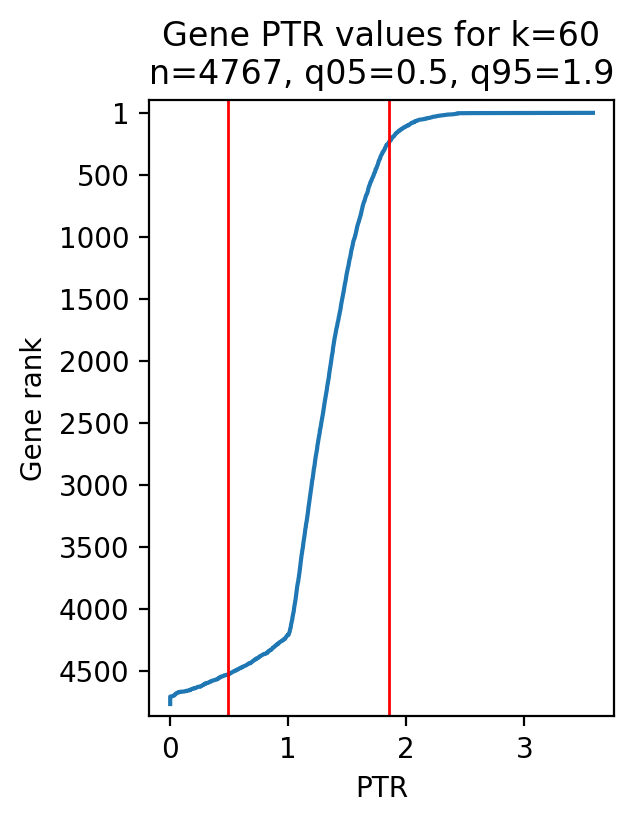

In [8]:
peak_to_trough_analysis.plot_ptrs_per_gene()

In [9]:
peak_to_trough_analysis.k_sorted_genes.head(10)

,rank,gene,ptr,spellman
orf_name,,,,
YEL021W,0,URA3,3.581579,False
YPL061W,1,ALD6,2.680842,True
YOL086C,2,ADH1,2.565713,False
YCR005C,3,CIT2,2.439018,False
YPR159W,4,KRE6,2.438348,True
YJL048C,5,UBX6,2.431816,False
YNL145W,6,MFA2,2.43166,True
YOR348C,7,PUT4,2.428654,False
YNR024W,8,MPP6,2.419809,False


In [10]:
peak_to_trough_analysis.k_sorted_genes[peak_to_trough_analysis.k_sorted_genes.gene == 'CLB2']

,rank,gene,ptr,spellman
orf_name,,,,
YPR119W,1465,CLB2,1.464533,True


In [11]:
peak_to_trough_analysis.k_sorted_genes.tail(10)

,rank,gene,ptr,spellman
orf_name,,,,
YLL064C,4757,PAU18,0.00001,False
YLR466W,4758,YRF1-4,0.00001,False
YFL058W,4759,THI5,0.00001,False
YCL069W,4760,VBA3,0.00001,False
YNL336W,4761,COS1,0.00001,False
YGL261C,4762,PAU11,0.00001,False
YCR038C,4763,BUD5,0.00001,False
YFL061W,4764,DDI2,0.00001,False
YNL334C,4765,SNO2,0.00001,False


## Evaluating different metrics to summarize gene PTR's

Next, we will evaluate other metrics that can capture a larger summary of the PTR image per gene. 

Metrics:
- Mean
- Median
- Quantiles: 80, 20

Evaluation:
- Plot a set of 20 genes and their PTR images, and evaluate how each metric measures up per gene.


In [70]:
mean = peak_to_trough_analysis.summarize_ptrs(np.mean)
median = peak_to_trough_analysis.summarize_ptrs(np.median)
q95 = peak_to_trough_analysis.compute_q_vals(0.95)

In [73]:
from src.ptr_analysis_plotter import plot_metric_examples_quantiles

In [112]:
from src.ptr_analysis_plotter import PTRAnalysisPlotter

plotter = PTRAnalysisPlotter(peak_to_trough_analysis, mean)


In [113]:
plotter.set_quantiles([1, 0.995, 0.99, 0.95, 0.9,
                       0.5, 0.4, 0.3, 0.05, 0.01, 0.005, 0])


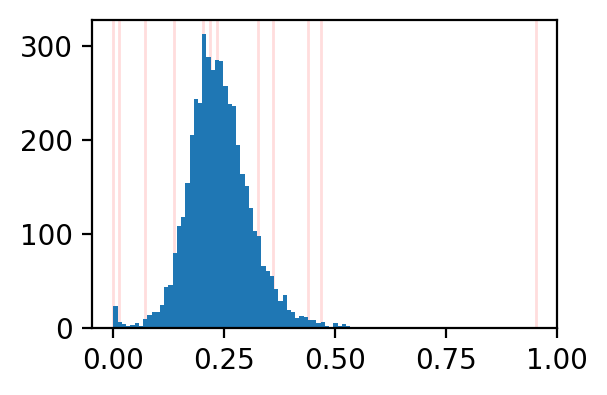

In [114]:
plotter.plot_distribution()

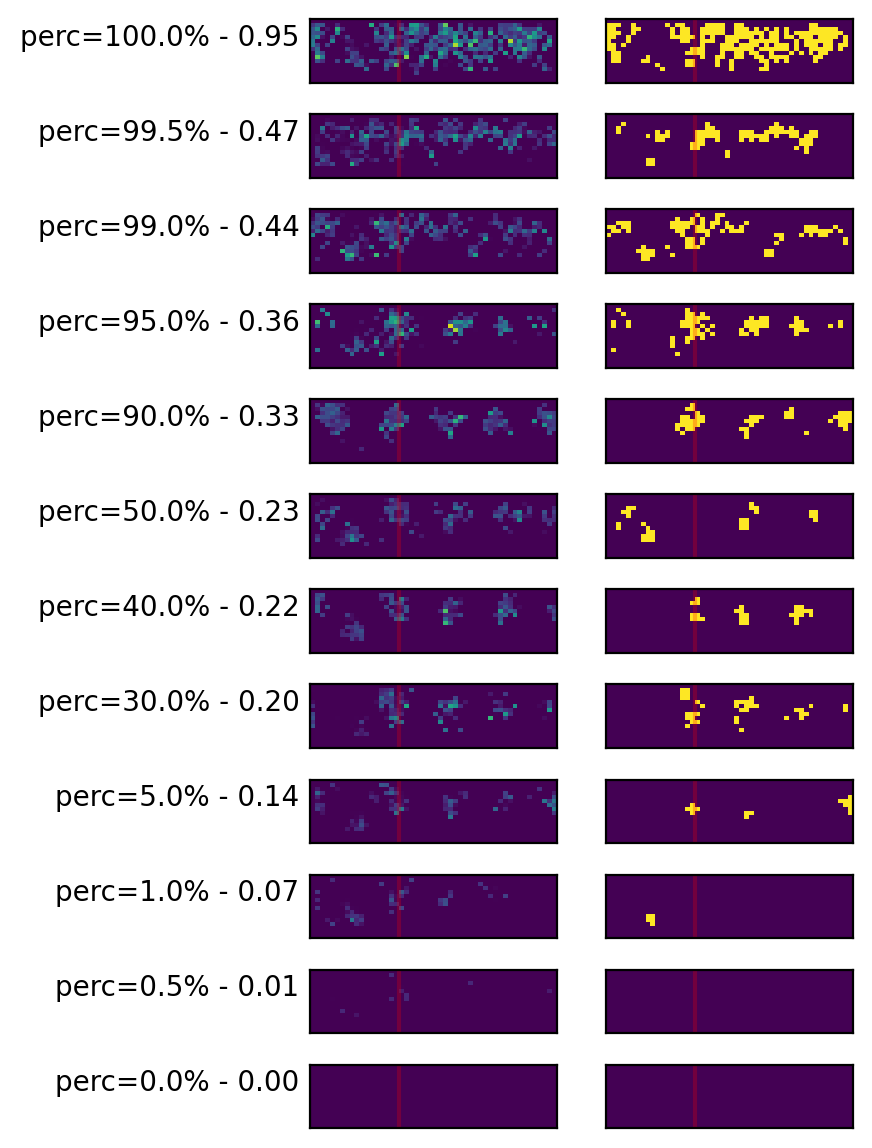

In [118]:
plotter.plot_metric_examples_quantiles()
